In [6]:
import numpy as np
import random
from copy import deepcopy

class Semantics:
    def __init__(self, utterances, truth_calc):
        """
        utterances: list of possible utterances (e.g., ["red", "blue"])
        """
        self.utterances = utterances
        self.truth_calc = truth_calc

    def utterance_space(self):
        """
        Return the set of utterances. `n` can be used if space depends on world size.
        """
        return self.utterances

    def is_true(self, utt, obs):
        """
        Returns True/False if utterance is true in a given state.
        """
        return self.truth_calc(utt, obs)

class World:
    def __init__(self, theta, world_parameters, obs_model, obs_generator):
        """
        thetas: list of possible latent states
        obs_model: function (theta, obs) -> likelihood P(obs | theta)
        """
        self.theta = theta
        self.world_parameters = world_parameters
        self.obs_model = obs_model
        self.obs_generator = obs_generator
        self.all_obs = None

    def obs_prob(self, obs, theta):
        """
        Return P(obs | theta).
        """
        return self.obs_model(obs, theta)
    
    def generate_all_obs(self):
        """
        Generate all possible observations using the provided generator function.
        """
        return self.obs_generator(world_parameters=self.world_parameters)
    
    def sample_obs(self):
        """
        Sample an observation according to P(obs | self.theta).
        """
        if self.all_obs is not None:
            all_obs = self.all_obs
        else:
            all_obs = self.generate_all_obs()
            self.all_obs = all_obs
        probs = np.array([self.obs_prob(obs, self.theta) for obs in all_obs])
        probs = probs / probs.sum()  # normalize to avoid floating-point issues
        return random.choices(all_obs, weights=probs, k=1)[0]

class Belief:
    def __init__(self, values, prior=None):
        """
        values: list of possible joint states, e.g. [(theta, psi), ...]
        prior: optional list of probabilities of same length
        """
        self.values = values
        if prior is None:
            self.prob = np.ones(len(values)) / len(values)
        else:
            self.prob = np.array(prior, dtype=float)
            self.prob /= np.sum(self.prob)

    def update(self, likelihoods):
        """
        likelihoods: array of same length as values
        """
        likelihoods = np.array(likelihoods, dtype=float)
        self.prob *= likelihoods
        if np.sum(self.prob) > 0:
            self.prob /= np.sum(self.prob)

    def as_dict(self):
        return dict(zip(self.values, self.prob))

    def marginal(self, index):
        """
        Compute marginal distribution over one coordinate.
        index = 0 for theta, 1 for psi
        """
        marg = {}
        for (theta, psi), p in zip(self.values, self.prob):
            key = (theta, psi)[index]
            marg[key] = marg.get(key, 0.0) + p
        return marg

class Speaker0:
    def __init__(self, thetas, semantics, world):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.semantics = semantics
        self.world = world
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterances_theta = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterances_theta = {}  # reset cached utterance distributions
        
        
        return self.belief_theta.as_dict()

    def dist_over_utterances_obs(self, obs):
        """
        For a literal speaker:
        Return uniform distribution over all utterances that are true for the given observation.
        """
        utterances = self.semantics.utterance_space()
        
        # Find all utterances that are true for this observation
        true_utterances = [utt for utt in utterances if self.semantics.is_true(utt, obs)]
        
        # uniform over the true utterances
        p = 1.0 / len(true_utterances)
        probs_dict = {utt: (p if utt in true_utterances else 0.0) for utt in utterances}
        
        return probs_dict

    def dist_over_utterances_theta(self, theta):
        if theta in self.utterances_theta:
            return self.utterances_theta[theta]
        probs = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs).items():
                probs[utt] += prob * obs_prob
        self.utterances_theta[theta] = probs
        return probs
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances(obs)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]

class Listener0:
    def __init__(self, thetas, speaker, world, semantics):
        """
        Listener maintains a joint belief P(theta, psi).
        """
        self.state_belief = Belief(thetas)
        self.speaker = speaker
        self.world = world
        self.semantics = semantics
        
        self.hist = [deepcopy(self.state_belief)]
        
        self.prior_utt = None
        self.obs_utt = {}

    def infer_state(self, utt):
        """
        Compute posterior distribution P(theta, psi | utt) ∝ P(utt | theta, psi) * prior.
        """
        likelihoods = []
        for state in self.state_belief.values:
            # Call speaker model for likelihood
            utt_dist = self.speaker.dist_over_utterances_theta(state)
            likelihoods.append(utt_dist.get(utt, 0.0))
        
        # Posterior
        posterior = Belief(self.state_belief.values, self.state_belief.prob.copy())
        posterior.update(likelihoods)
        return posterior
    
    def infer_obs(self, utt):
        if utt in self.obs_utt:
            return self.obs_utt[utt]
        result = {}
        obs_prob = self.distribution_over_obs()
        utt_priors = self.prior_over_utt()
        for obs in self.world.generate_all_obs():
            # get precomputed priors (cached internally)     
            result[obs] = self.speaker.dist_over_utterances_obs(obs)[utt] * obs_prob[obs] / utt_priors[utt]
        self.obs_utt[utt] = result
        return result

    def distribution_over_obs(self):
        result = {}
        for obs in self.world.generate_all_obs():
            listener_obs = 0
            for (theta, theta_prob) in self.state_belief.as_dict().items():
                listener_obs += self.world.obs_prob(obs, theta) * theta_prob
            result[obs] = listener_obs
        return result
    
    def prior_over_utt(self):
        if self.prior_utt is not None:
            return self.prior_utt
        utt_priors = {}
        for utt in self.semantics.utterance_space():
            total = 0.0
            for obs_case in self.world.generate_all_obs():
                literal_speaker_utterance_obscase_val = self.speaker.dist_over_utterances_obs(obs_case)
                for (theta_case, theta_prob) in self.state_belief.as_dict().items():
                    obs_prior = self.world.obs_prob(obs_case, theta_case)
                    total += (
                        literal_speaker_utterance_obscase_val[utt]
                        * obs_prior
                        * theta_prob
                    )
            utt_priors[utt] = total
        self.prior_utt = utt_priors
        return utt_priors
    
    def update(self, utt):
        """
        Replace the current belief with the posterior after hearing utterance.
        """
        new_belief = self.infer_state(utt)
        self.state_belief = new_belief
        
        self.prior_utt = None
        self.obs_utt = {}
        
        self.hist.append(deepcopy(self.state_belief))
        
        return self.state_belief.as_dict()


class Speaker1:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

        return self.belief_theta.as_dict()

    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        result = self.listener.infer_obs(utt)
        for (obs_case, prob) in result.items():
            self.informativeness_obs_utt[(obs_case, utt)] = prob
        return result[obs]
    
    def get_informativeness_obs(self, obs):
        result = {}
        for utt in self.semantics.utterance_space():
            result[utt] = self.listener.infer_obs(utt)[obs]
        return result

    def get_persuasiveness(self, pers):
        if pers in self.persuasiveness_psi:
            return self.persuasiveness_psi[pers]
        utterances = self.semantics.utterance_space()
        result = {u: 0.0 for u in utterances}

        for utt in utterances:
            if pers == "inf":
                result[utt] = 1
            elif pers == "high":
                for (theta, theta_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += theta * theta_prob
            elif pers == "low":
                for (theta, theta_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += theta * theta_prob
                result[utt] = 1 - result[utt]
        self.persuasiveness_psi[pers] = result
        return result

    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0
        
        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if info_val > 0:
                score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]


class Listener1:
    def __init__(self, thetas, psis, speaker, world, semantics, listener_type, alpha=1.0):
        """
        Listener maintains a joint belief P(theta, psi).
        """
        if listener_type == "inf":
            psis = ["inf"]
        joint_values = [(theta, psi) for theta in thetas for psi in psis]
        self.state_belief = Belief(joint_values)
        self.speaker = speaker
        self.world = world
        self.semantics = semantics
        self.psis = psis
        self.alpha = alpha
        self.hist = [deepcopy(self.state_belief)]
        
        self.obs_psi_utt = {}
        self.obs_psi = None
        self.prior_utt = None
        self.obs_utt = {}

    def infer_state(self, utt):
        """
        Compute posterior distribution P(theta, psi | utt) ∝ P(utt | theta, psi) * prior.
        """
        likelihoods = []
        for state in self.state_belief.values:
            # Call speaker model for likelihood
            utt_dist = self.speaker.dist_over_utterances_theta(state[0], state[1])
            likelihoods.append(utt_dist.get(utt, 0.0))
        
        # Posterior
        posterior = Belief(self.state_belief.values, self.state_belief.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def infer_obs(self, utt):
        if utt in self.obs_utt:
            return self.obs_utt[utt]
        result = {}
        obs_psi_utt = self.infer_obs_psi(utt)
        for obs in self.world.generate_all_obs():
            for psi in self.psis:
                result[obs] = result.get(obs, 0.0) + obs_psi_utt[(obs, psi)]
        self.obs_utt[utt] = result
        return result
    
    def infer_obs_psi(self, utt):
        if utt in self.obs_psi_utt:
            return self.obs_psi_utt[utt]
        result = {(obs,psi): 0.0 for obs in self.world.generate_all_obs() for psi in self.psis}
        obs_psi= self.distribution_over_obs_psi()
        utt_priors = self.prior_over_utt()
        for obs in self.world.generate_all_obs():
            # get precomputed priors (cached internally)   
            for psi in self.psis:
                result[(obs, psi)] = self.speaker.dist_over_utterances_obs(obs, psi)[utt] * obs_psi[(obs, psi)] / utt_priors[utt]
        self.obs_psi_utt[utt] = result
        return result
    
    def distribution_over_obs_psi(self):
        if self.obs_psi is not None:
            return self.obs_psi
        
        result = {(obs,psi): 0.0 for obs in self.world.generate_all_obs() for psi in self.psis}
        for (state, state_prob) in self.state_belief.as_dict().items():
            for obs in self.world.generate_all_obs():
                cur_obs_prob = self.world.obs_prob(obs, state[0])
                result[(obs, state[1])] += cur_obs_prob * state_prob
        self.obs_psi_utt = result
        return result
    
    def prior_over_utt(self):
        if self.prior_utt is not None:
            return self.prior_utt
        utt_priors = {utt: 0.0 for utt in self.semantics.utterance_space()}
        obs_psi_dist = self.distribution_over_obs_psi()
        for obs_case in self.world.generate_all_obs():
            for psi in self.psis:
                pragmatic_speaker_utterance_obscase_val = self.speaker.dist_over_utterances_obs(obs_case, psi)
                for utt in self.semantics.utterance_space():
                    utt_priors[utt] += pragmatic_speaker_utterance_obscase_val[utt] * obs_psi_dist[(obs_case, psi)]
                    
        self.prior_utt = utt_priors
        return utt_priors
    
    def update(self, utt):
        """
        Replace the current belief with the posterior after hearing utterance.
        """
        new_belief = self.infer_state(utt)
        self.state_belief = new_belief
        self.hist.append(deepcopy(self.state_belief))
        
        self.obs_psi_utt = {}
        self.obs_psi = None
        self.prior_utt = None
        self.obs_utt = {}
        
        return self.state_belief
    
    def marginal_theta(self):
        """
        Return the marginal distribution over theta.
        """
        theta_probs = {}
        for (theta, psi), p in zip(self.state_belief.values, self.state_belief.prob):
            theta_probs[theta] = theta_probs.get(theta, 0.0) + p
        return theta_probs

    def marginal_psi(self):
        """
        Return the marginal distribution over psi.
        """
        psi_probs = {}
        for (theta, psi), p in zip(self.state_belief.values, self.state_belief.prob):
            psi_probs[psi] = psi_probs.get(psi, 0.0) + p
        return psi_probs


class Speaker2:
    def __init__(self, thetas, listener, semantics, world, alpha=1.0, psi="inf"):
        """
        Speaker stores a belief over theta and reasons using a listener model.
        
        thetas    : list of possible theta values
        listener  : a Listener object from the lower level (e.g. L0 for S1)
        semantics : object defining utterance space, truth conditions
        alpha     : rationality parameter
        pers      : persuasion type ("inf", "high", "low")
        """
        self.thetas = thetas
        self.belief_theta = Belief(thetas)
        self.listener = listener
        self.semantics = semantics
        self.world = world
        self.alpha = alpha
        self.psi = psi
        
        self.hist = [deepcopy(self.belief_theta)]
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}

    def infer_state(self, obs):
        """
        Compute posterior over theta given an observation (Bayes update).
        """
        likelihoods = []
        for theta in self.thetas:
            likelihoods.append(self.world.obs_prob(obs, theta))

        posterior = Belief(self.thetas, self.belief_theta.prob.copy())
        posterior.update(likelihoods)
        return posterior

    def update(self, obs):
        """
        Update internal belief over theta after seeing an observation.
        """
        self.belief_theta = self.infer_state(obs)
        self.hist.append(deepcopy(self.belief_theta))
        
        self.utterance_theta_psi = {}
        self.informativeness_obs_utt = {}
        self.persuasiveness_psi = {}
        self.utterances_obs_psi = {}
        return self.belief_theta.as_dict()

    def get_informativeness_obs_utt(self, obs, utt):
        if (obs, utt) in self.informativeness_obs_utt:
            return self.informativeness_obs_utt[(obs, utt)]
        result = self.listener.infer_obs(utt)
        for (obs_case, prob) in result.items():
            self.informativeness_obs_utt[(obs_case, utt)] = prob
        return result[obs]
    
    def get_informativeness_obs(self, obs):
        result = {}
        for utt in self.semantics.utterance_space():
            result[utt] = self.listener.infer_obs(utt)[obs]
        return result

    def get_persuasiveness(self, pers):
        if pers in self.persuasiveness_psi:
            return self.persuasiveness_psi[pers]
        utterances = self.semantics.utterance_space()
        result = {u: 0.0 for u in utterances}

        for utt in utterances:
            if pers == "inf":
                result[utt] = 1
            elif pers == "high":
                for (state, state_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += state[0] * state_prob
            elif pers == "low":
                for (state, state_prob) in self.listener.infer_state(utt).as_dict().items():
                    result[utt] += state[0] * state_prob
                result[utt] = 1 - result[utt]
        self.persuasiveness_psi[pers] = result
        return result

    def dist_over_utterances_obs(self, obs, psi):
        """
        Distribution over utterances given observation.
        Uses informativeness + persuasiveness.
        """
        if (obs, psi) in self.utterances_obs_psi:
            return self.utterances_obs_psi[(obs, psi)]
        utterances = self.semantics.utterance_space()
        persuasiveness = self.get_persuasiveness(psi)
        scores = []
        if psi == "inf":
            beta = 1.0
        else:
            beta = 0.0
        
        for utt in utterances:
            info_val = self.get_informativeness_obs_utt(obs, utt)
            pers_val = persuasiveness[utt]
            if info_val > 0:
                score = (info_val ** (self.alpha * beta)) * (pers_val ** (self.alpha * (1 - beta)))
            else:
                score = 0.0
            scores.append(score)

        scores = np.array(scores)
        probs = scores / np.sum(scores)
        self.utterances_obs_psi[(obs, psi)] = dict(zip(utterances, probs))
        return self.utterances_obs_psi[(obs, psi)]

    def dist_over_utterances_theta(self, theta, psi):
        if (theta, psi) in self.utterance_theta_psi:
            return self.utterance_theta_psi[(theta, psi)]
        result = {u: 0.0 for u in self.semantics.utterance_space()}
        for obs in self.world.generate_all_obs():
            obs_prob = self.world.obs_prob(obs, theta)
            for utt, prob in self.dist_over_utterances_obs(obs, psi).items():
                result[utt] += prob * obs_prob
        self.utterance_theta_psi[(theta, psi)] = result
        return result
    
    def sample_utterance(self, obs):
        """
        Sample an utterance from the utterance distribution.
        """
        dist = self.dist_over_utterances_obs(obs, self.psi)
        utterances, probs = zip(*dist.items())
        return random.choices(utterances, weights=probs, k=1)[0]

def Game(thetas, psis, semantics, world, speaker_type="inf", listener_type="inf", alpha=1.0, rounds=1):
    """
    Play a game of communication between a speaker and a listener.
    """
    literal_speaker = Speaker0(thetas, semantics=semantics, world=world)
    literal_listener = Listener0(thetas, literal_speaker, semantics=semantics, world=world)
    pragmatic_speaker_1 = Speaker1(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
    pragmatic_listener_1 = Listener1(thetas, psis, pragmatic_speaker_1, semantics=semantics, world=world, alpha=alpha, listener_type=listener_type)
    pragmatic_speaker_2 = Speaker2(thetas, pragmatic_listener_1, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
    
    for r in range(rounds):
        print(f"--- Round {r+1} ---")
        obs = world.sample_obs()
        print(f"World theta: {world.theta}, observation: {obs}")
        
        utt = pragmatic_speaker_2.sample_utterance(obs)
        print(f"Speaker uttered: {utt}")
        
        pragmatic_speaker_2.update(obs)
        pragmatic_listener_1.update(utt)
        pragmatic_speaker_1.update(obs)
        literal_listener.update(utt)
        literal_speaker.update(obs)
    return pragmatic_speaker_2, pragmatic_listener_1, pragmatic_speaker_1, literal_listener, literal_speaker

import uuid
import datetime
import json
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

# ----------------------
# Experiment logger
# ----------------------
@dataclass
class ExperimentLogger:
    params: Dict[str, Any]
    id: str = field(default_factory=lambda: str(uuid.uuid4()))
    timestamp: str = field(default_factory=lambda: datetime.datetime.now().isoformat())
    rounds: List[Dict[str, Any]] = field(default_factory=list)
    agent_histories: Dict[str, Optional[List[Any]]] = field(default_factory=dict)  # filled by finalize()

    def log_round(self, round_idx: int, world_theta: Any, observation: Any, utterance: Any, extra: Dict[str, Any] = None):
        """Log the minimal per-round info. Do NOT copy agent.hist here."""
        entry = {
            "round": round_idx,
            "world_theta": world_theta,
            "observation": observation,
            "utterance": utterance
        }
        if extra:
            entry.update(extra)
        self.rounds.append(entry)

    def finalize(self, agents: Dict[str, Any], copy_hist: bool = True):
        """
        Snapshot agents' `hist` attributes once at the end of the experiment.
        This intentionally stores per-agent `hist` only once (not every round).
        """
        for name, agent in agents.items():
            hist = getattr(agent, "hist", None)  # your agents use self.hist = []
            if hist is None:
                self.agent_histories[name] = None
            else:
                self.agent_histories[name] = list(hist) if copy_hist else hist

    # helpers for serializing (safe fallback: str(...) for non-JSON-serializable objects)
    def _make_serializable(self, obj):
        try:
            json.dumps(obj)
            return obj
        except (TypeError, OverflowError):
            return str(obj)

    def to_dict(self, serializable: bool = False) -> Dict[str, Any]:
        meta = {"id": self.id, "timestamp": self.timestamp, "params": self.params}
        rounds = self.rounds
        agent_histories = self.agent_histories
        if serializable:
            meta["params"] = {k: self._make_serializable(v) for k, v in self.params.items()}
            rounds = [{k: self._make_serializable(v) for k, v in r.items()} for r in rounds]
            agent_histories = {k: ([self._make_serializable(v) for v in hist] if hist is not None else None)
                               for k, hist in agent_histories.items()}
        return {"meta": meta, "rounds": rounds, "agent_histories": agent_histories}

    def to_json(self, filename: Optional[str] = None, serializable: bool = True) -> Optional[str]:
        """Write to a file (or return json string if filename is None)."""
        d = self.to_dict(serializable=serializable)
        j = json.dumps(d, indent=2)
        if filename:
            with open(filename, "w") as f:
                f.write(j)
            return None
        return j


# ----------------------
# Runner functions
# ----------------------
def run_game(thetas, psis, semantics, world,
             speaker_type="inf", listener_type="inf", alpha=1.0, rounds: int = 1,
             verbose: bool = False) -> Tuple[ExperimentLogger, Dict[str, Any]]:
    """
    Modern runner: returns (logger, agents_dict).
    - logger.rounds contains minimal per-round logs (no agent.hist duplication).
    - logger.finalize(...) is called automatically to snapshot agent.hist once.
    - agents_dict contains references to the live agent objects (so caller can inspect agent.hist)
    """
    # initialize agents (your existing constructors)
    literal_speaker = Speaker0(thetas, semantics=semantics, world=world)
    literal_listener = Listener0(thetas, literal_speaker, semantics=semantics, world=world)
    pragmatic_speaker_1 = Speaker1(thetas, literal_listener, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)
    pragmatic_listener_1 = Listener1(thetas, psis, pragmatic_speaker_1, semantics=semantics, world=world, alpha=alpha, listener_type=listener_type)
    pragmatic_speaker_2 = Speaker2(thetas, pragmatic_listener_1, semantics=semantics, world=world, alpha=alpha, psi=speaker_type)

    params = {
        "thetas": thetas,
        "psis": psis,
        "semantics": str(semantics),
        "world": str(world),
        "speaker_type": speaker_type,
        "listener_type": listener_type,
        "alpha": alpha,
        "rounds": rounds,
    }
    logger = ExperimentLogger(params=params)

    agents = {
        "pragmatic_speaker_2": pragmatic_speaker_2,
        "pragmatic_listener_1": pragmatic_listener_1,
        "pragmatic_speaker_1": pragmatic_speaker_1,
        "literal_listener": literal_listener,
        "literal_speaker": literal_speaker,
    }

    for r in range(1, rounds + 1):
        if verbose:
            print(f"--- Round {r} ---")
        obs = world.sample_obs()
        if verbose:
            print(f"World theta: {world.theta}, observation: {obs}")

        utt = pragmatic_speaker_2.sample_utterance(obs)
        if verbose:
            print(f"Speaker uttered: {utt}")

        # belief updates (your original order)
        pragmatic_speaker_2.update(obs)
        pragmatic_listener_1.update(utt)
        pragmatic_speaker_1.update(obs)
        literal_listener.update(utt)
        literal_speaker.update(obs)

        # minimal per-round log (no agent.hist here)
        logger.log_round(r, world.theta, obs, utt)

    # snapshot agent.hist once
    logger.finalize(agents)
    return logger, agents


# ----------------------
# Backwards-compatible wrapper
# ----------------------
def Game(thetas, psis, semantics, world,
         speaker_type="inf", listener_type="inf", alpha=1.0, rounds: int = 1, verbose: bool = False):
    """
    Backwards-compatible Game(...) which returns the same five agents as before,
    BUT also attaches the ExperimentLogger to the top-level returned speaker as
    `pragmatic_speaker_2.experiment_log` for convenience.
    Old call-pattern:
        ps2, pl1, ps1, ll, ls = Game(...)
    New convenience:
        ps2.experiment_log  # contains ExperimentLogger with rounds + final agent hist snapshots
    """
    logger, agents = run_game(thetas, psis, semantics, world,
                              speaker_type=speaker_type, listener_type=listener_type,
                              alpha=alpha, rounds=rounds, verbose=verbose)
    # attach logger to the returned top-level speaker for backward compat
    agents["pragmatic_speaker_2"].experiment_log = logger
    # return agents in the old tuple order (so your existing code doesn't break)
    return (agents["pragmatic_speaker_2"],
            agents["pragmatic_listener_1"],
            agents["pragmatic_speaker_1"],
            agents["literal_listener"],
            agents["literal_speaker"])
    
from scipy.special import binom
import math
from functools import lru_cache

def generate_all_observations(world_parameters):
    """
    Generate all possible observation histograms for n patients and m sessions.
    Each histogram is a tuple of length m+1, summing to n.
    """
    n = world_parameters["n"]
    m = world_parameters["m"]
    observations = []

    def helper(current, depth, remaining):
        if depth == m:
            current.append(remaining)
            observations.append(tuple(current))
            current.pop()
            return
        for i in range(remaining + 1):
            current.append(i)
            helper(current, depth + 1, remaining - i)
            current.pop()

    helper([], 0, n)
    return observations

@lru_cache(maxsize=None)
def utterance_is_true(u, obs):
    """Evaluate if utterance u = (q1, q2, pred) is true given obs[n x m]"""
    if sum(obs) > 1:
        q1, q2, pred = u
        n = sum(obs)
        m = len(obs) - 1
        k = 0
        if pred == "ineffective":
            obs = obs[::-1]  # Reverse obs to treat "ineffective" as the last element
        
        # Step 1: apply q2 to each patient
        if q2 == "none":
            k = obs[0]
        elif q2 == "some":
            k = sum(obs[1:])
        elif q2 == "most":
            k = sum(obs[math.floor(m / 2) + (m % 2) : ])
        elif q2 == "all":
            k = obs[-1]

        # Step 2: apply q1 across patients
        if q1 == "none":
            return k == 0
        elif q1 == "some":
            return k >= 1
        elif q1 == "most":
            return k > (n / 2)
        elif q1 == "all":
            return k == n
    else:
        """Evaluate if utterance u = (q2, pred) is true given obs[1 x m]"""
        q2, pred = u
        m = len(obs) - 1
        patient_score = obs.index(1) if pred == "effective" else m - obs.index(1)

        if q2 == "none":
            return patient_score == 0
        elif q2 == "some":
            return patient_score > 0
        elif q2 == "most":
            return patient_score > (m / 2)
        elif q2 == "all":
            return patient_score == m

@lru_cache(maxsize=None)  
def multinomial(params):
    if len(params) == 1:
        return 1
    return binom(sum(params), params[-1]) * multinomial(params[:-1])

@lru_cache(maxsize=None)
def get_obs_prob(obs, theta):
    n = sum(obs)
    m = len(obs) - 1
    flat_prob = 1
    def helper(effective):
        return math.comb(m, effective) * (theta ** effective) * ((1 - theta) ** (m - effective))
    for i in range(len(obs)):
        flat_prob *= helper(i) ** obs[i]
    return flat_prob * multinomial(obs)

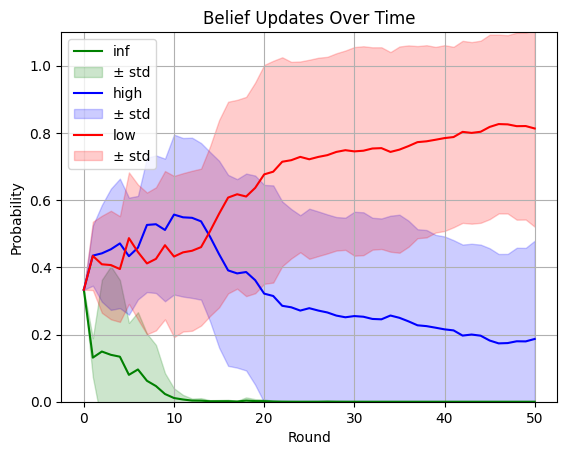

In [20]:
import pickle
psis_aggregated = {"inf": [], "high": [], "low": []}
psis_mean = {"inf": [], "high": [], "low": []}
psis_std = {"inf": [], "high": [], "low": []}
# Load
for i in range(10):
    with open(f"exp_{i+1}_s-low_l-vig_t-0.8_agents.pkl", "rb") as f:
        agents_reloaded = pickle.load(f)
    psis = {"inf": [], "high": [], "low": []}
    for belief in agents_reloaded["pragmatic_listener_1"].hist:
        for (psi, prob) in belief.marginal(1).items():
            psis[psi].append(prob)
    for psi in psis_aggregated.keys():
        psis_aggregated[psi].append(psis[psi])

for psi in psis_aggregated.keys():
    psis_mean[psi] = np.mean(psis_aggregated[psi], axis=0)
    psis_std[psi] = np.std(psis_aggregated[psi], axis=0)

#plotting

    


import matplotlib.pyplot as plt
for psi, values in psis_mean.items():
    #make inf green, high blue, low red
    if psi == "inf":
        plt.plot(values, label=psi, color="green")
        plt.fill_between(range(0, len(values)), psis_mean[psi] - psis_std[psi], psis_mean[psi] + psis_std[psi], color="green", alpha=0.2, label="± std")
    elif psi == "high":
        plt.plot(values, label=psi, color="blue")
        plt.fill_between(range(0, len(values)), psis_mean[psi] - psis_std[psi], psis_mean[psi] + psis_std[psi], color="blue", alpha=0.2, label="± std")
    elif psi == "low":
        plt.plot(values, label=psi, color="red")
        plt.fill_between(range(0, len(values)), psis_mean[psi] - psis_std[psi], psis_mean[psi] + psis_std[psi], color="red", alpha=0.2, label="± std")
plt.ylim(0, 1.1)
#add grid
plt.grid(True)
plt.xlabel("Round")
plt.ylabel("Probability")
plt.title("Belief Updates Over Time")
plt.legend()
plt.show()

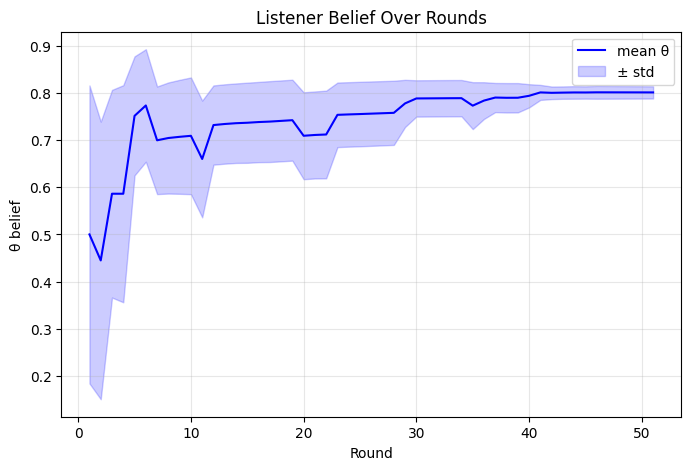

In [10]:
import numpy as np

def summarize_beliefs(belief_hist):
    thetas = np.array(sorted(belief_hist[0].keys()))
    means, ses = [], []
    for dist in belief_hist:
        ps = np.array([dist[th] for th in thetas])
        mean = np.sum(thetas * ps)
        var = np.sum((thetas - mean)**2 * ps)
        std = np.sqrt(var)
        # SE = std / sqrt(N); here N=1 distribution per round, so just use std as uncertainty
        se = std
        means.append(mean)
        ses.append(se)
    return np.arange(1, len(belief_hist)+1), np.array(means), np.array(ses)

theta_beliefs = []
for belief in agents_reloaded["pragmatic_listener_1"].hist:
    theta_beliefs.append(belief.marginal(0))

rounds, means, ses = summarize_beliefs(theta_beliefs)

plt.figure(figsize=(8,5))
plt.plot(rounds, means, label="mean θ", color="blue")
plt.fill_between(rounds, means - ses, means + ses, color="blue", alpha=0.2, label="± std")

plt.xlabel("Round")
plt.ylabel("θ belief")
plt.title("Listener Belief Over Rounds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()